# Training Curves — Spatial-LLaVA Visual Grounding

Plots training and validation metrics from saved `results/*/metrics.json` files.

**Models:**
- **Main**: LoRA fine-tuned LLaVA + MLP regression head (10 epochs)
- **Ablation**: Frozen LLaVA backbone + MLP head only (10 epochs)

**To reproduce:** Run all cells in order. Requires `matplotlib` and the metrics JSON files in `results/`.

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12, 'figure.dpi': 150})

In [2]:
with open('../results/main/metrics.json') as f:
    main_metrics = json.load(f)
with open('../results/ablation/metrics.json') as f:
    ablation_metrics = json.load(f)

main_history = main_metrics['history']
ablation_history = ablation_metrics['history']

main_epochs = [h['epoch'] for h in main_history]
ablation_epochs = [h['epoch'] for h in ablation_history]

print(f"Main model: {len(main_history)} epochs")
print(f"Ablation model: {len(ablation_history)} epochs")

Main model: 10 epochs
Ablation model: 10 epochs


## 1. Training & Validation Loss

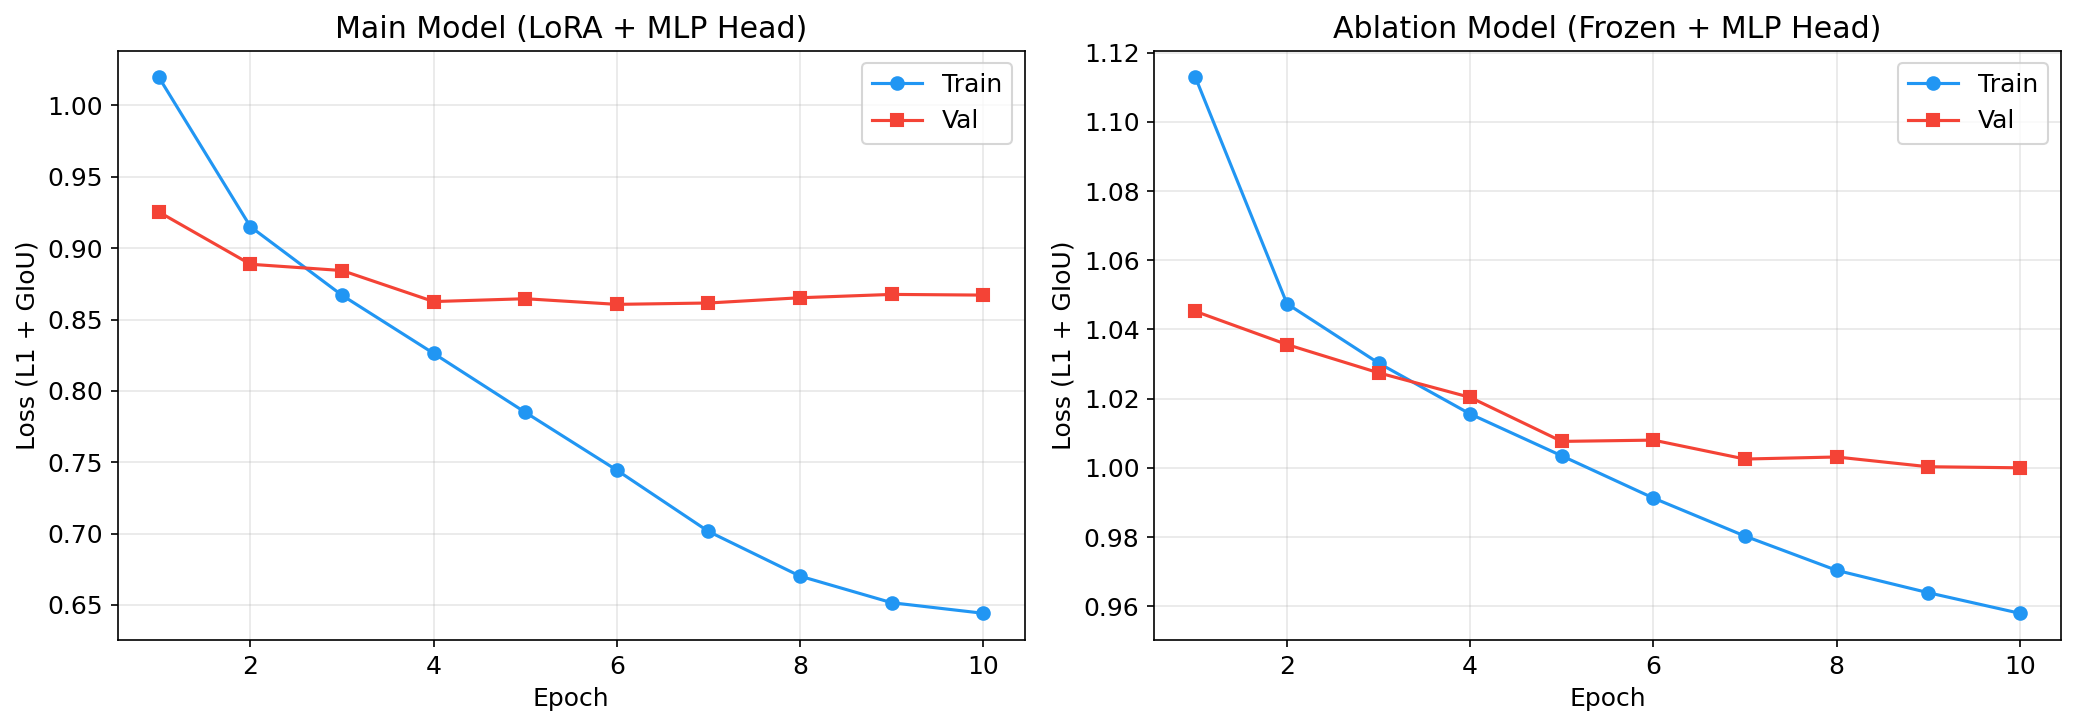

Saved: results/training_loss_curves.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Main model
ax = axes[0]
ax.plot(main_epochs, [h['train_loss'] for h in main_history], 'o-', color='#2196F3', label='Train')
ax.plot(main_epochs, [h['val_loss'] for h in main_history], 's-', color='#F44336', label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (L1 + GIoU)')
ax.set_title('Main Model (LoRA + MLP Head)')
ax.legend()
ax.grid(True, alpha=0.3)

# Ablation model
ax = axes[1]
ax.plot(ablation_epochs, [h['train_loss'] for h in ablation_history], 'o-', color='#2196F3', label='Train')
ax.plot(ablation_epochs, [h['val_loss'] for h in ablation_history], 's-', color='#F44336', label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (L1 + GIoU)')
ax.set_title('Ablation Model (Frozen + MLP Head)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_loss_curves.png', bbox_inches='tight')
plt.show()
print('Saved: results/training_loss_curves.png')

## 2. IoU Curves (Train vs Val)

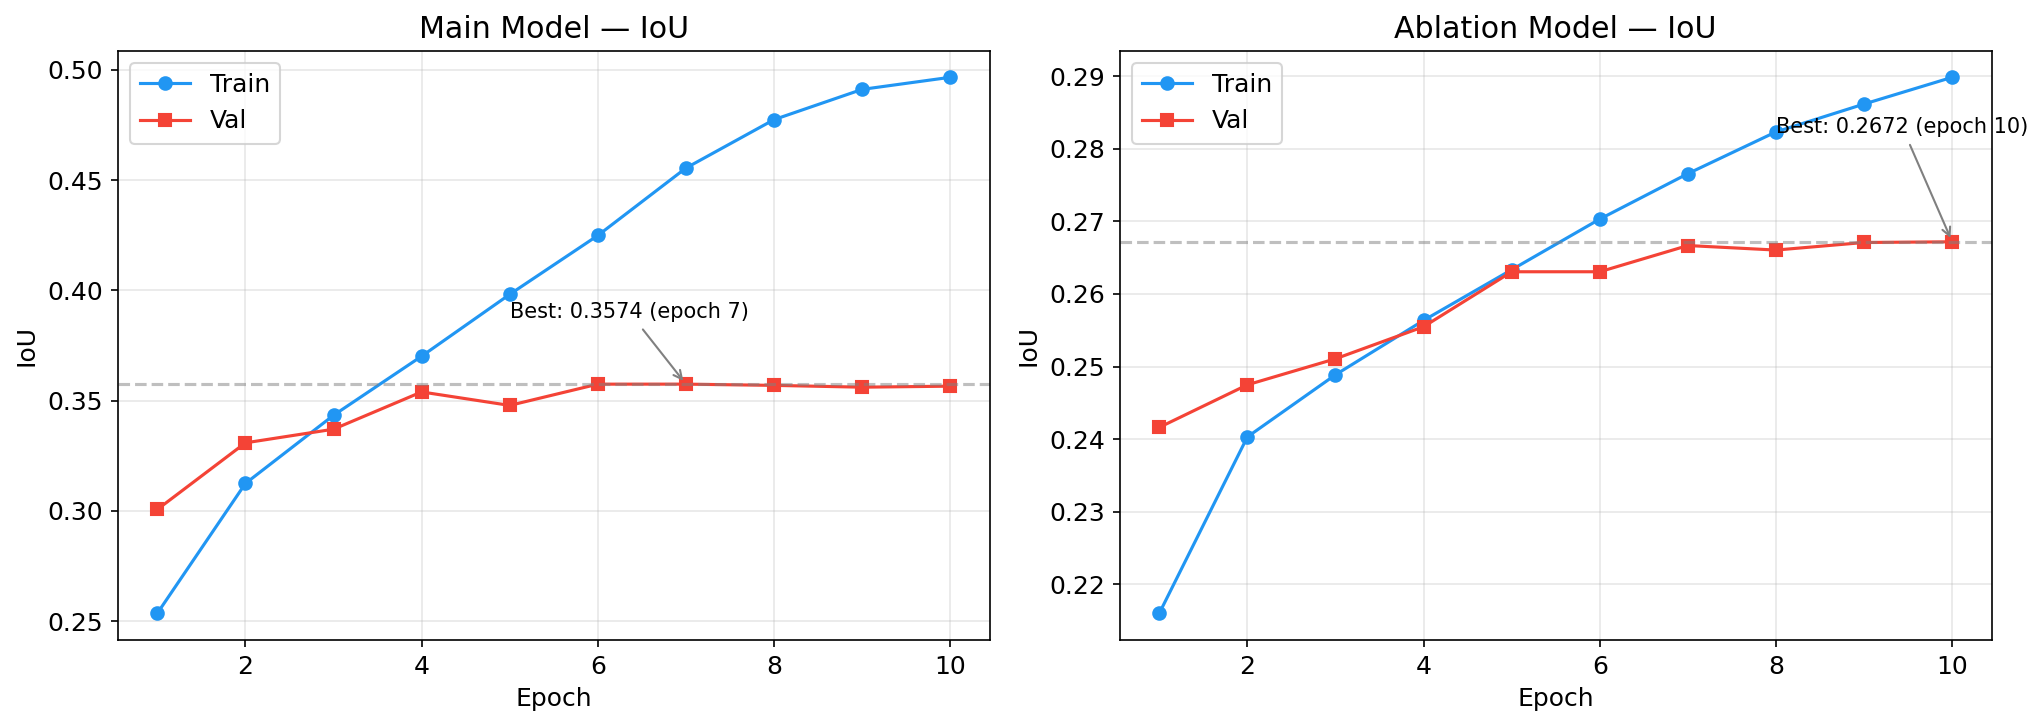

Saved: results/training_iou_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Main model
ax = axes[0]
ax.plot(main_epochs, [h['train_iou'] for h in main_history], 'o-', color='#2196F3', label='Train')
ax.plot(main_epochs, [h['val_iou'] for h in main_history], 's-', color='#F44336', label='Val')
best_epoch = max(main_history, key=lambda h: h['val_iou'])['epoch']
best_iou = max(h['val_iou'] for h in main_history)
ax.axhline(y=best_iou, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'Best: {best_iou:.4f} (epoch {best_epoch})', xy=(best_epoch, best_iou),
            xytext=(best_epoch - 2, best_iou + 0.03), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_title('Main Model — IoU')
ax.legend()
ax.grid(True, alpha=0.3)

# Ablation model
ax = axes[1]
ax.plot(ablation_epochs, [h['train_iou'] for h in ablation_history], 'o-', color='#2196F3', label='Train')
ax.plot(ablation_epochs, [h['val_iou'] for h in ablation_history], 's-', color='#F44336', label='Val')
best_epoch_ab = max(ablation_history, key=lambda h: h['val_iou'])['epoch']
best_iou_ab = max(h['val_iou'] for h in ablation_history)
ax.axhline(y=best_iou_ab, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'Best: {best_iou_ab:.4f} (epoch {best_epoch_ab})', xy=(best_epoch_ab, best_iou_ab),
            xytext=(best_epoch_ab - 2, best_iou_ab + 0.015), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_title('Ablation Model — IoU')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_iou_curves.png', bbox_inches='tight')
plt.show()
print('Saved: results/training_iou_curves.png')

## 3. RMSE & MAE Curves

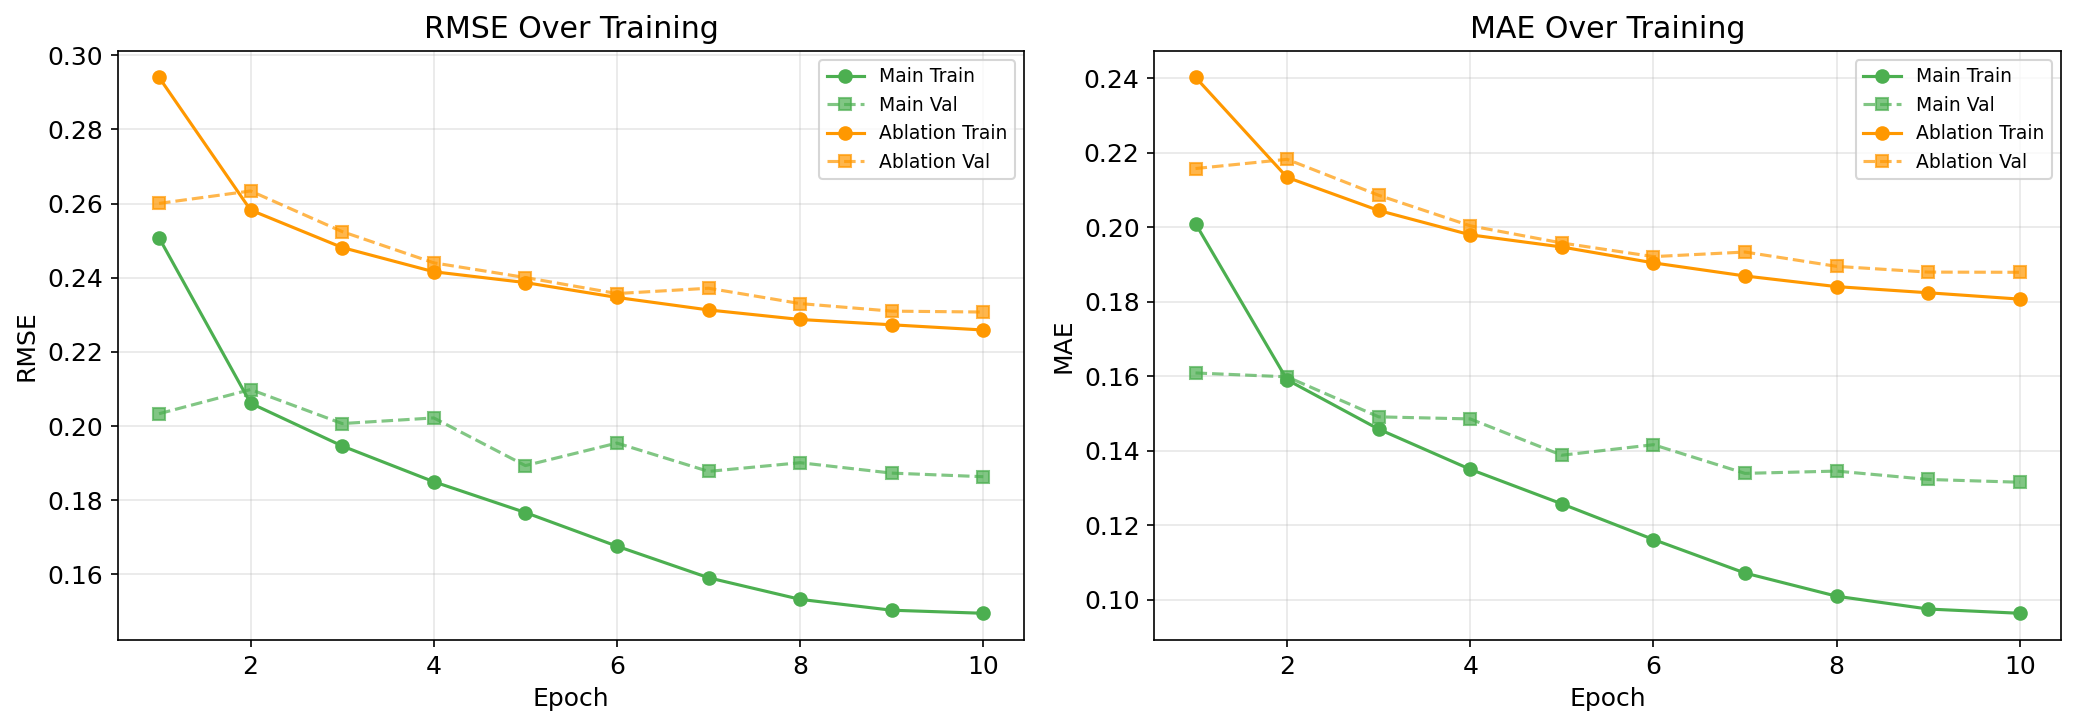

Saved: results/training_rmse_mae_curves.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
ax = axes[0]
ax.plot(main_epochs, [h['train_rmse'] for h in main_history], 'o-', color='#4CAF50', label='Main Train')
ax.plot(main_epochs, [h['val_rmse'] for h in main_history], 's--', color='#4CAF50', label='Main Val', alpha=0.7)
ax.plot(ablation_epochs, [h['train_rmse'] for h in ablation_history], 'o-', color='#FF9800', label='Ablation Train')
ax.plot(ablation_epochs, [h['val_rmse'] for h in ablation_history], 's--', color='#FF9800', label='Ablation Val', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.set_title('RMSE Over Training')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# MAE
ax = axes[1]
ax.plot(main_epochs, [h['train_mae'] for h in main_history], 'o-', color='#4CAF50', label='Main Train')
ax.plot(main_epochs, [h['val_mae'] for h in main_history], 's--', color='#4CAF50', label='Main Val', alpha=0.7)
ax.plot(ablation_epochs, [h['train_mae'] for h in ablation_history], 'o-', color='#FF9800', label='Ablation Train')
ax.plot(ablation_epochs, [h['val_mae'] for h in ablation_history], 's--', color='#FF9800', label='Ablation Val', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE')
ax.set_title('MAE Over Training')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/training_rmse_mae_curves.png', bbox_inches='tight')
plt.show()
print('Saved: results/training_rmse_mae_curves.png')

## 4. Learning Rate Schedule

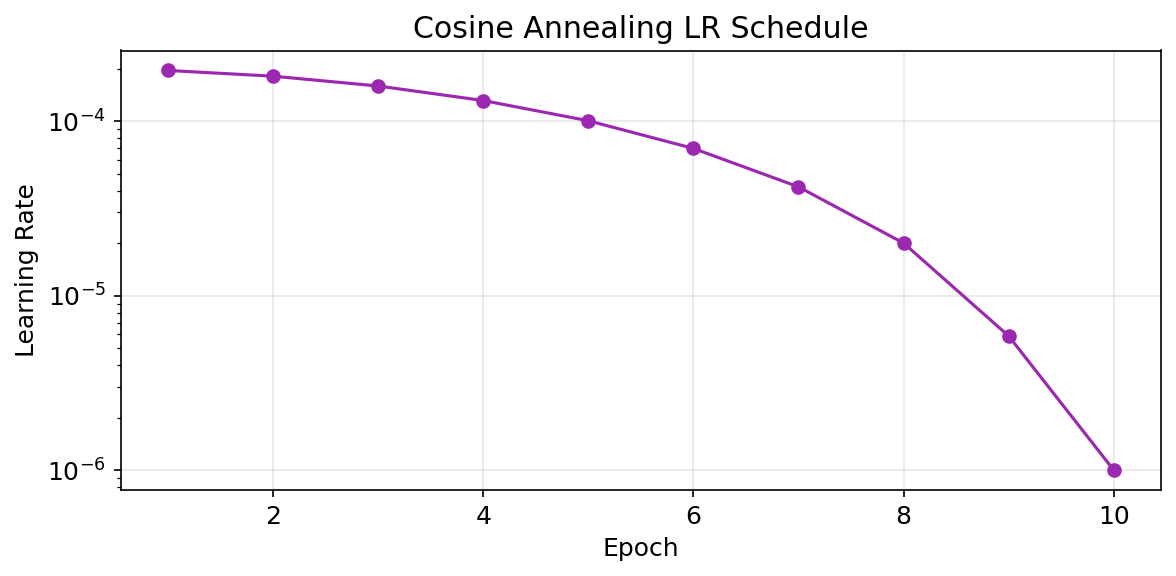

Saved: results/lr_schedule.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(main_epochs, [h['lr'] for h in main_history], 'o-', color='#9C27B0')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Cosine Annealing LR Schedule')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lr_schedule.png', bbox_inches='tight')
plt.show()
print('Saved: results/lr_schedule.png')

## 5. Final Model Comparison (Test Set)

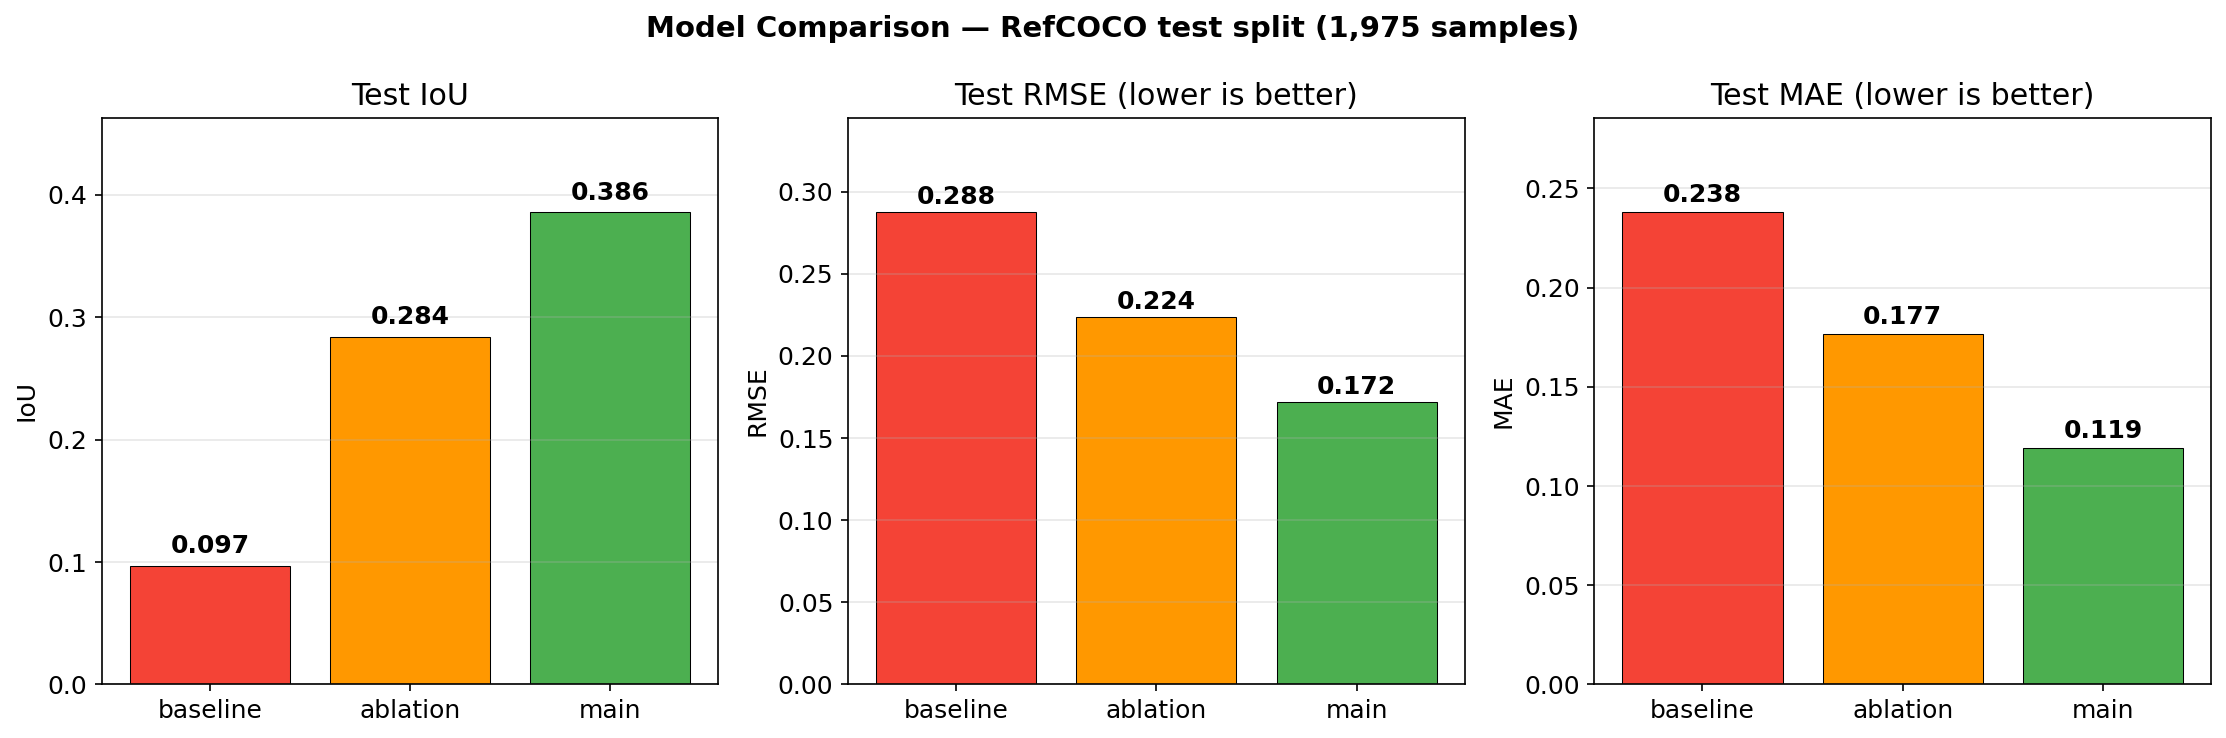

Saved: results/model_comparison.png

Improvements:
  ablation_vs_baseline: +192.7%
  main_vs_baseline: +297.5%
  main_vs_ablation: +35.8%


In [7]:
with open('../results/evaluation/comparison.json') as f:
    comparison = json.load(f)

results = comparison['results']
model_names = ['baseline', 'ablation', 'main']
colors = ['#F44336', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# IoU
ious = [results[m]['iou'] for m in model_names]
axes[0].bar(model_names, ious, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('IoU')
axes[0].set_title('Test IoU')
for i, v in enumerate(ious):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(ious) * 1.2)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE
rmses = [results[m]['rmse'] for m in model_names]
axes[1].bar(model_names, rmses, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('RMSE')
axes[1].set_title('Test RMSE (lower is better)')
for i, v in enumerate(rmses):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, max(rmses) * 1.2)
axes[1].grid(True, alpha=0.3, axis='y')

# MAE
maes = [results[m]['mae'] for m in model_names]
axes[2].bar(model_names, maes, color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('MAE')
axes[2].set_title('Test MAE (lower is better)')
for i, v in enumerate(maes):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
axes[2].set_ylim(0, max(maes) * 1.2)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle(f"Model Comparison — {comparison['evaluated_on']}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/model_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: results/model_comparison.png')

print(f"\nImprovements:")
for k, v in comparison['improvements'].items():
    print(f"  {k}: {v}")

## 6. Overfitting Analysis

The gap between train and val IoU shows the degree of overfitting.

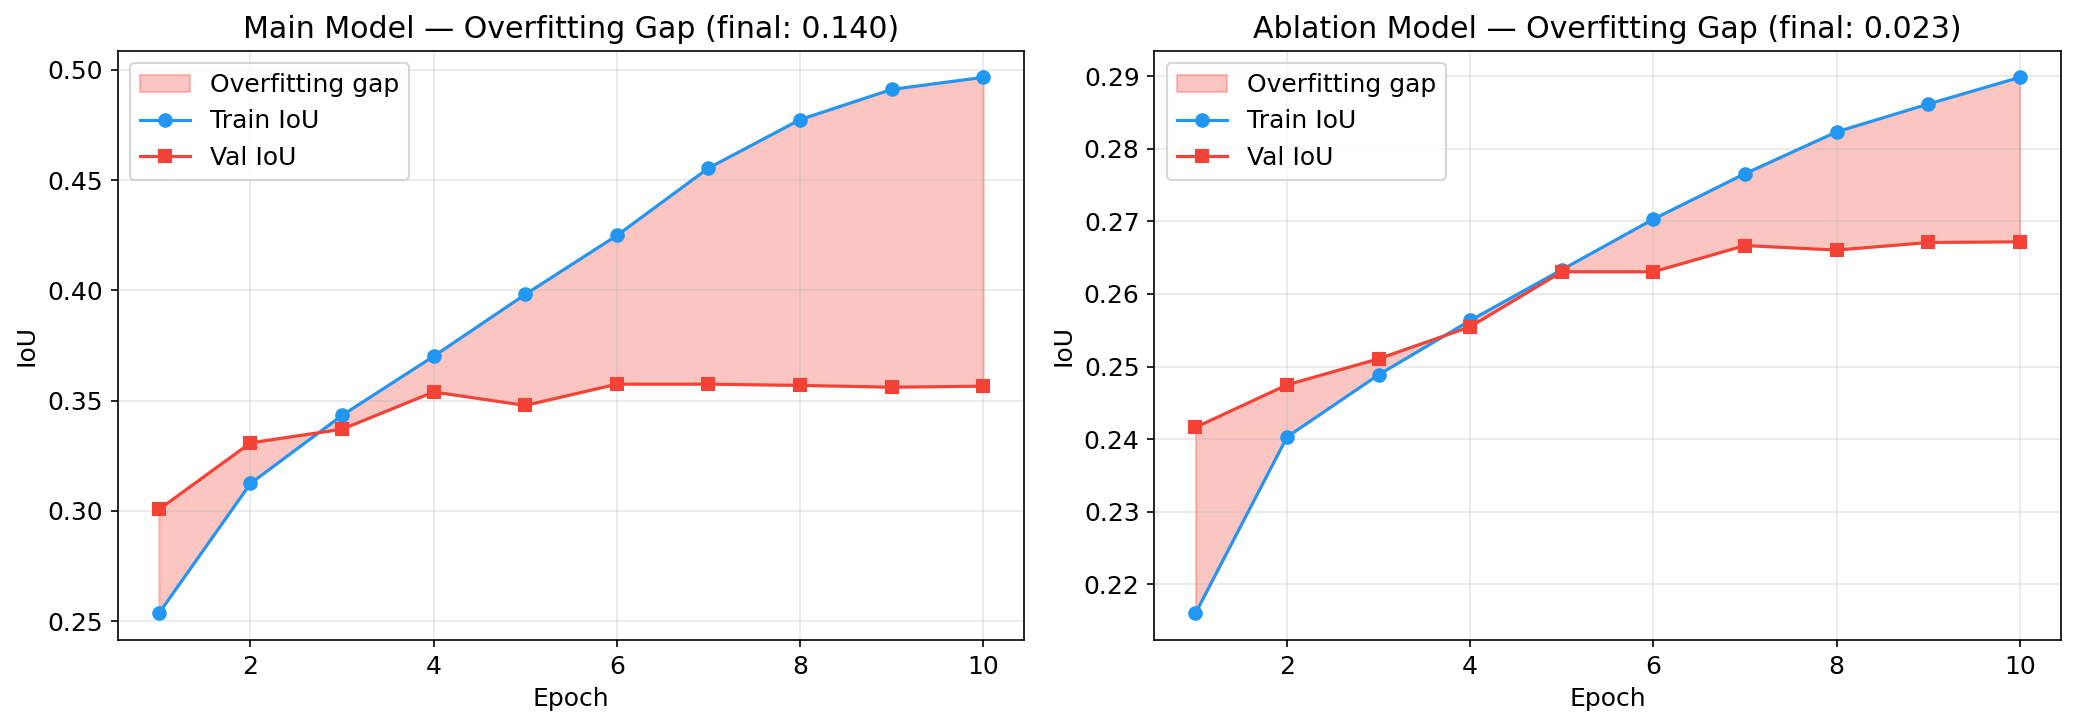

Saved: results/overfitting_analysis.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Main model gap
ax = axes[0]
train_ious = [h['train_iou'] for h in main_history]
val_ious = [h['val_iou'] for h in main_history]
gaps = [t - v for t, v in zip(train_ious, val_ious)]
ax.fill_between(main_epochs, val_ious, train_ious, alpha=0.3, color='#F44336', label='Overfitting gap')
ax.plot(main_epochs, train_ious, 'o-', color='#2196F3', label='Train IoU')
ax.plot(main_epochs, val_ious, 's-', color='#F44336', label='Val IoU')
ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_title(f'Main Model — Overfitting Gap (final: {gaps[-1]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Ablation model gap
ax = axes[1]
train_ious_ab = [h['train_iou'] for h in ablation_history]
val_ious_ab = [h['val_iou'] for h in ablation_history]
gaps_ab = [t - v for t, v in zip(train_ious_ab, val_ious_ab)]
ax.fill_between(ablation_epochs, val_ious_ab, train_ious_ab, alpha=0.3, color='#F44336', label='Overfitting gap')
ax.plot(ablation_epochs, train_ious_ab, 'o-', color='#2196F3', label='Train IoU')
ax.plot(ablation_epochs, val_ious_ab, 's-', color='#F44336', label='Val IoU')
ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_title(f'Ablation Model — Overfitting Gap (final: {gaps_ab[-1]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/overfitting_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: results/overfitting_analysis.png')

## 7. Bias Audit

Analyze model performance across subgroups (object size, expression length, aspect ratio).

**To reproduce:** `python scripts/bias_audit.py`

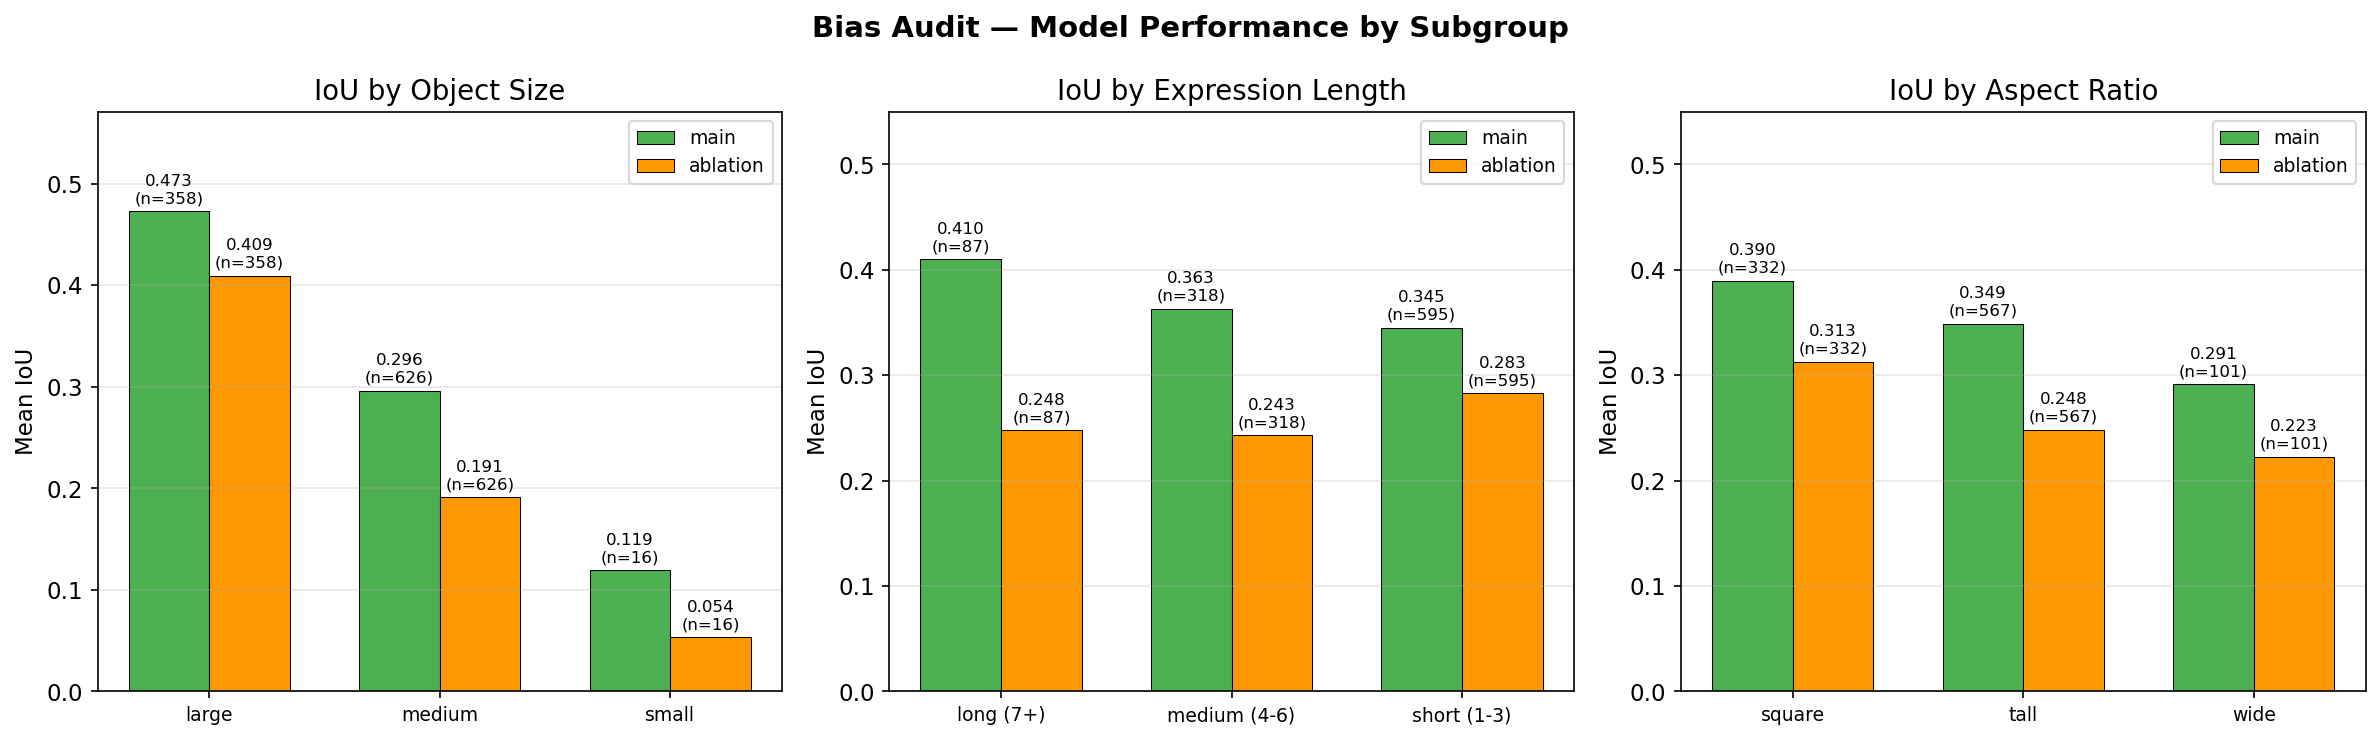

To regenerate: python scripts/bias_audit.py
Source data: results/main/predictions.json, results/ablation/predictions.json
Output: results/bias_audit.png, results/bias_audit.json


In [9]:
from IPython.display import Image as IPImage, display
display(IPImage(filename='../results/bias_audit.png'))
print('To regenerate: python scripts/bias_audit.py')
print('Source data: results/main/predictions.json, results/ablation/predictions.json')
print('Output: results/bias_audit.png, results/bias_audit.json')

## 8. Failure Analysis & IoU Distribution

Shows worst predictions, failure categories, and IoU distribution histogram.

**To reproduce:** `python scripts/failure_cases.py`

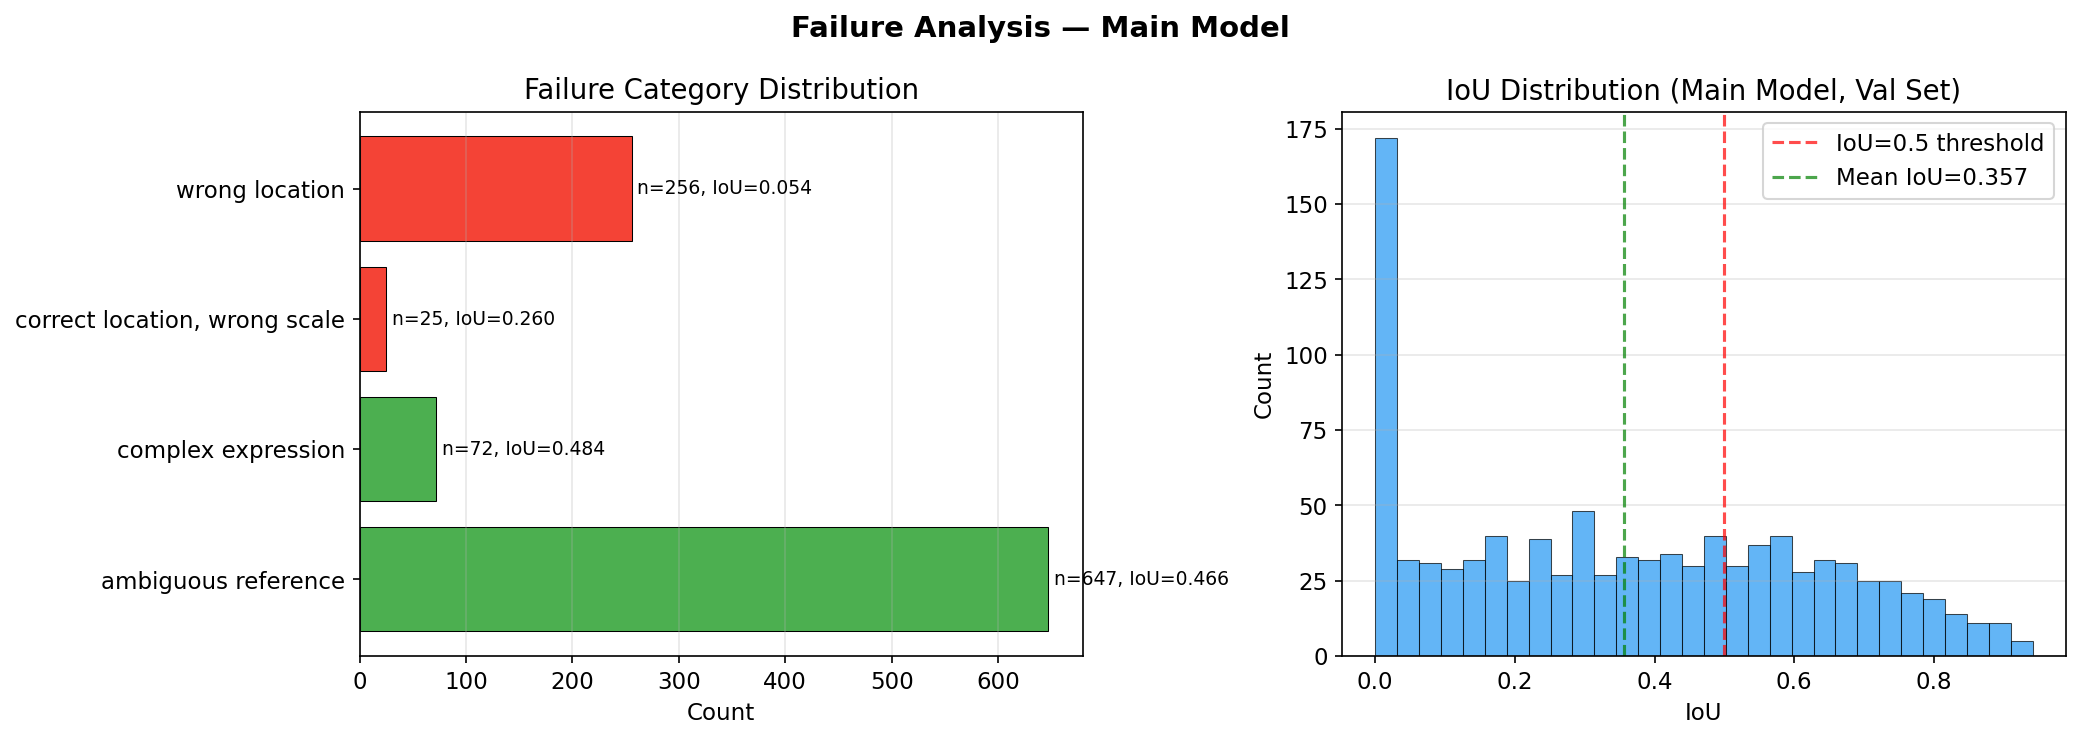

To regenerate: python scripts/failure_cases.py
Source data: results/main/predictions.json
Output: results/failure_summary.png, results/failure_cases/*.png, results/failure_cases/failure_analysis.json


In [10]:
display(IPImage(filename='../results/failure_summary.png'))
print('To regenerate: python scripts/failure_cases.py')
print('Source data: results/main/predictions.json')
print('Output: results/failure_summary.png, results/failure_cases/*.png, results/failure_cases/failure_analysis.json')

---

## Figure Reproduction Index

Every figure in the report can be reproduced from saved JSON data. No GPU or retraining required.

| Figure | Output File | How to Reproduce | Source Data |
|--------|-------------|-----------------|-------------|
| Training loss curves | `results/training_loss_curves.png` | Run cell 4 above | `results/main/metrics.json`, `results/ablation/metrics.json` |
| IoU curves | `results/training_iou_curves.png` | Run cell 6 above | Same as above |
| RMSE & MAE curves | `results/training_rmse_mae_curves.png` | Run cell 8 above | Same as above |
| LR schedule | `results/lr_schedule.png` | Run cell 10 above | Same as above |
| Model comparison bars | `results/model_comparison.png` | Run cell 12 above | `results/evaluation/comparison.json` |
| Overfitting analysis | `results/overfitting_analysis.png` | Run cell 14 above | `results/main/metrics.json`, `results/ablation/metrics.json` |
| Bias audit | `results/bias_audit.png` | `python scripts/bias_audit.py` | `results/main/predictions.json`, `results/ablation/predictions.json` |
| Failure analysis | `results/failure_summary.png` | `python scripts/failure_cases.py` | `results/main/predictions.json` |
| Failure examples | `results/failure_cases/worst_*.png` | `python scripts/failure_cases.py` | `results/main/predictions.json` + COCO images |
| Example predictions | `results/main/examples/*.png` | `python pipeline/step2_train_main.py` (saved during training) | Checkpoints + COCO images |
| Latency benchmark | `results/latency_benchmark.json` | `python scripts/benchmark_latency.py` (requires running API server) | Live API |

**Environment:** Python 3.11, matplotlib, numpy. See `requirements.txt` for full dependencies.
**Seed:** 42 (set in all training scripts for reproducibility)
**Hardware:** Training on NVIDIA A100-SXM4-80GB (SUTD AI Mega Cluster)